# **NLP Project 2026: Web Novel and Light Novel labels predictions**
##### **Authors: *Arno LESAGE (no. 22202985), Minh Quan Hoang (no. 22509118)***

greta.damo@inria.fr

## 1- Research Questions
**Requirements (120 words):** In the world of bookworms, being able to tell the different genres of a Light Novel (LN) or a Web Novel (WN) based on its description is very common. Unfortunately, this apparent simplicity represent a quite difficult task for computers. Using the not so known [*Web/Light Novel Dataset*](https://www.kaggle.com/datasets/premshinde/weblight-novel-dataset), our goal is to predict, from the description of a book, the associated genre(s). We emits the hypothesis (already used for movies classification) that a description unveils a particular semantic depending on the genres they are associated with. As instance, a LN with the `Horror` tag is more likely to have a *gore* description than a `Romance/School Life` LN. Additionally, we also emit the hypothesis of high correlation between genres (`Adventure` implies `Fantasy` or `Drama/Romance`).  

**Required Reflection:** 

**[Q1] Why is your research question non trivial?** Multiple difficulties arise with this research question, but the two main difficulties are the high number of genres (35 in our dataset), but also their correlation together, which would render discrimination attempt difficult (Note: maybe it correlation could be turn into strength).

**[Q2] What linguistic phenomenon does it involve?** The linguistics phenomenon involved we want to capture here is the underlying semantics of the different genres. We expect more joyful "words" and sentences structures for genres like `Romance/Comedy`, more tendentious for `Adult/Ecchi/Harem/Gender Bender`, more youthful for `Shoujo/Shounen/Adventure` and so on.

**[Q3] What would falsify your hypothesis?** A possible justification for our hypothesis being falsified could be that the translation of the description from the original language (Chinese, Korean, Japanese, Vietnamese, ...) to english removed some details and damaged the underlying semantics. 

## 2.1 - Dataset Selection
The dataset chosen for this project is the [*Web/Light Novel Dataset*](https://www.kaggle.com/datasets/premshinde/weblight-novel-dataset) (original-wn-dataset.csv). 

- **Source:** Kaggle, Web/Light Novel Dataset, Prem Shinde, 2024
- **Domain:** Literature, Web/Light Novels, Asian Literature
- **Label Distribution:** Multilabel, Heterogeneous (some labels have 106, others 7523), "exponential" unbalanced distributions of labels.
- **Potential biases:** Correlation between books origins and labels, correlation between labels, traduction failures of Chinese, Japanese, Korean, Vietnamese, ... to English.
- **Ethical Consideration:** Methodology for extraction is unknown. Apart from this, this dataset does not exhibit particular ethicals considerations.
- **Size:** 11770 labeled documents, 74.87MB.
- **Main Content:** Title, Description [Classifiers], Source (URL), Genres [Predicted variable], Tags (Sub genres), related series, authors, artists, original language...

Despite relatively poor documentation, this dataset was chosen as it is more complete (more instances) in comparison with other available alternative, possess a bigger variety of genres and tags, but also is easier to navigate. Alternative could have been:
- [RanobeDB](https://ranobedb.org/database-dumps): SQL Database containing series and books for manga, LN and WN. (difficult to navigate),
- [MyAnimeList Dataset](https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset): Very complete and good documentation, but has less variety and may not contains LN and WN independent productions.
- [Anime Title Dataset](https://huggingface.co/datasets/realoperator42/anime-titles-dataset): Complete, but has very low number of instances (<1000) and Anime Only.

More informations on the shape of the dataset in the part **(2.1 - In Depth)**

### **Libraries**

In [26]:
# Default package
import re
from collections import Counter
from itertools import chain

# Visualisation
%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Base ML
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

# Multilabel ML
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

### **Import the dataset (original-wn)**

In [27]:
df = pd.read_csv("datasets/original-wn-dataset.csv")
df.describe(include="all")

,novel_id,url,title,associated_names,img_url,showtype,genres,tags,description,related_series,...,publishers,en_pubs,release_frequency,weekly_rank,monthly_rank,all_time_rank,monthly_rank_reading_list,all_time_rank_reading_list,total_reading_list_rank,chapters
count,11770.000000,11770,11770,11770,11770,11700,11770,11770,11766,11770,...,11770,11770,11769,11770,11770,11770,11770,11770,11770.000000,11770
unique,NaN,11770,11768,11619,10159,20,6014,11215,11676,1325,...,1213,69,3721,474,2600,8282,3091,6533,NaN,10488
top,NaN,after-the-breakup-i-went-viral-in-the-entertai...,The Imperial Concubine Just Wants To Be a Salt...,[],https://www.novelupdates.com/img/noimagefound.jpg,Web Novel (CN),['Fantasy' 'Romance'],[],N/A\n,"{'related_series': array([], dtype=object), 't...",...,['jjwxc'],[],Every 2000 Day(s),#2000,#2000,#14613,#15649,#11754,NaN,"{'chapters': array([], dtype=object), 'total': 0}"
freq,NaN,1,2,97,1607,5592,230,155,66,10398,...,2216,10454,118,6097,5699,13,418,13,NaN,1283
mean,34047.713084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1664.066950,NaN
std,19129.992708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2436.728268,NaN
min,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,NaN
25%,18403.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,NaN
50%,35094.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.000000,NaN
75%,50761.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981.000000,NaN


For our NLP classification task, we are interested on the following columns `novel_id`, `title`, `genres`, `tags` and `description`.

In [28]:
df_filtered = df.loc[:, ["novel_id", "title", "genres", "tags", "description"]]
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...",['Drama' 'Fantasy' 'Romance' 'Supernatural'],['Amnesia' 'Beautiful Female Lead' 'Clever Pro...,"Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,['Fantasy' 'Romance' 'Shoujo'],['Adventurers' 'Elemental Magic' 'Familiars' '...,A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,['Action' 'Adventure' 'Fantasy' 'Historical' '...,['Beautiful Female Lead' 'Businessmen' 'Childc...,"To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,['Romance' 'School Life' 'Shoujo'],['Female Protagonist' 'Modern Day' 'Short Stor...,"My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,['Psychological' 'Romance' 'Shounen Ai' 'Slice...,['Arranged Marriage' 'Calm Protagonist' 'Cold ...,Lin You He excelled in everything – his looks...


### **Preprocess Dataset Format**

Using the `.head()` command, we observe that the `genres` and `tags` columns are encoded into space separated list, which are not recognised in Python, so we will have to change the format to proper lists.

In [29]:
def colToList (x:str) -> list[str]:
    # Detect the separator
    x = re.sub(r"'[\n ].?'", ",",x)
    
    # Remove the indicator of the raw space separated list and split on coma
    xSplit = x.removeprefix("['").removesuffix("']").split(",")
    
    # Return the list where the text is capitalize (it is just prettier)
    return list(map(str.capitalize, xSplit))

# Apply the split
df_filtered.loc[:,"genres"] = df_filtered.loc[:,"genres"].apply(lambda x: colToList(x))
df_filtered.loc[:,"tags"] = df_filtered.loc[:,"tags"].apply(lambda x: colToList(x))
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...","[Drama, Fantasy, Romance, Supernatural]","[Amnesia, Beautiful female lead, Clever protag...","Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,"[Fantasy, Romance, Shoujo]","[Adventurers, Elemental magic, Familiars, Fema...",A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,"[Action, Adventure, Fantasy, Historical, Roman...","[Beautiful female lead, Businessmen, Childcare...","To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,"[Romance, School life, Shoujo]","[Female protagonist, Modern day, Short story, ...","My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,"[Psychological, Romance, Shounen ai, Slice of ...","[Arranged marriage, Calm protagonist, Cold pro...",Lin You He excelled in everything – his looks...


## 2.1 (and 3.1.) - in depth - Some stats on the dataset
Now that everything is correctly imported, we will observe some statistics on our dataset to understand it. First, we will try to understand what kind of language is used in our data.
##### **Description language** 
To achieve this goal, we will first take a look at the most frequent words in our dataset. We will build a function to compare with and without stopwords.

In [57]:
def plotDescriptionLanguage(df:pd.DataFrame, col="description", stopFiltered=True):
    descriptionList = list(map(str,df.loc[:,col].to_list()))
    descriptionString = " ".join(descriptionList)
    # Match all words and digits
    wordDescriptionList = re.findall(r"[\w\d-]+",descriptionString)

    # Remove the stopwords if asked
    wordDescriptionList = [i.capitalize() for i in wordDescriptionList if (i.lower() not in stop_words) or not stopFiltered]

    # Apply the counter
    wordDescriptionListCounter = Counter(wordDescriptionList)

    # Sort the counter
    wordDescriptionListCounterSorted = [[],[]]
    for word in sorted(wordDescriptionListCounter, key=lambda x:wordDescriptionListCounter[x], reverse=True):
        wordDescriptionListCounterSorted[0].append(word)
        wordDescriptionListCounterSorted[1].append(wordDescriptionListCounter[word])

    # Make a plot
    plt.close("all")
    sns.set_style("dark")
    sns.barplot(
        x=wordDescriptionListCounterSorted[1][:40],
        y=wordDescriptionListCounterSorted[0][:40],
        palette="BrBG"    
    )
    plt.title(f"Wordcount {'(stopwords filtered)' if stopFiltered else ''}")
    plt.xlabel("Wordcount")
    plt.ylabel("Words")

    plt.show()
    
    return wordDescriptionListCounterSorted
    

Now that we have the function, we can start without stopwords filtering:

C:\Users\arnol\AppData\Local\Temp\ipykernel_8060\1773452185.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


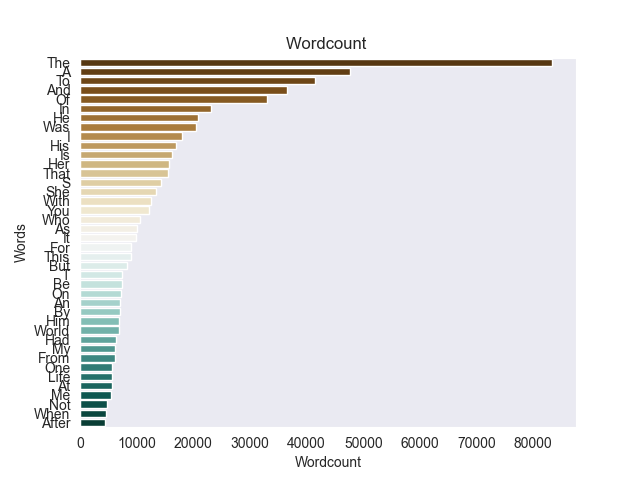

In [59]:
df_filteredWordCounter = plotDescriptionLanguage(df_filtered, stopFiltered=False)

Here, we quickly observe that, as expected, all of the most frequent words are stopwords (A, The, To, And, Of, ...). This is bad news. Indeed, these words in this context will not exhibits high semantic importance in the document, but could possess tremendous weights in our future embeddings. We will now do the same plot without stopwords (using `nltk` stopwords list for English).  

C:\Users\arnol\AppData\Local\Temp\ipykernel_8060\1773452185.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


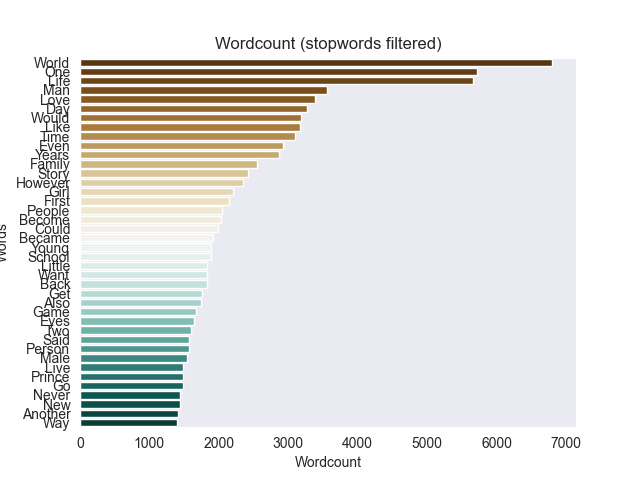

In [86]:
_ = plotDescriptionLanguage(df_filtered)

Here, we clearly observe the difference. Generic stopwords aside, we observe some interesting words like `World`, `Life`, `Prince`, `Story` and `Time`, which could possibly be tied to some genres like `Fantasy` or `Adventure` considering their popularity. Another predominant family emerges here with `School`, `Young`, `Family` and `Love` which are typical of the genres `School Life` and `Romance`. In the end, we really see some "specialised" topics compared to political, economical, scientific or newspapers texts that we are used to.

But now, what about the least used words and the frequency in global?

In [84]:
df_filteredWordDescription = pd.DataFrame(columns=["Word", "Frequency"])
df_filteredWordDescription["Word"] = pd.Series(df_filteredWordCounter[0])
df_filteredWordDescription["Frequency"] = pd.Series(df_filteredWordCounter[1])
df_filteredWordDescription

,Word,Frequency
0,The,83384
1,A,47692
2,To,41495
3,And,36481
4,Of,33092
...,...,...
41020,Strength-worshiping,1
41021,Adult-based,1
41022,Seryu,1
41023,Wisemen,1


Here, using the table, we observe that the nature of least used words could be categorised (broadly) in four categories: composed words (`Strength-worshiping`, `Adult-based`, `Good-nature`), names (`Tsuruki`, `Zhaoying`, `Ikaros`), specialised words (`Euthanasia`, `Canines`, `Serializing`) or non-English components (`Otouto`, `Giraffe`, `100g`, `1920`, `房事`).

Additionally, we observe that 22603 unique words (55.10%) appears less than 2 times and that even 16732 words (40.78%) appears only once. This observation will render necessary to filter rare words.

In the end, the proportion of words that could  be considered "frequent" (20 words or more) is of approximately 12.3%. Concerning "very frequent words" (100+ occurrences), only 3.64% of them can be considered that way. We can therefore clearly see the concentration in occurrences and the heterogeneity of the dictionary used.

Let's observe in more details this proposition: 

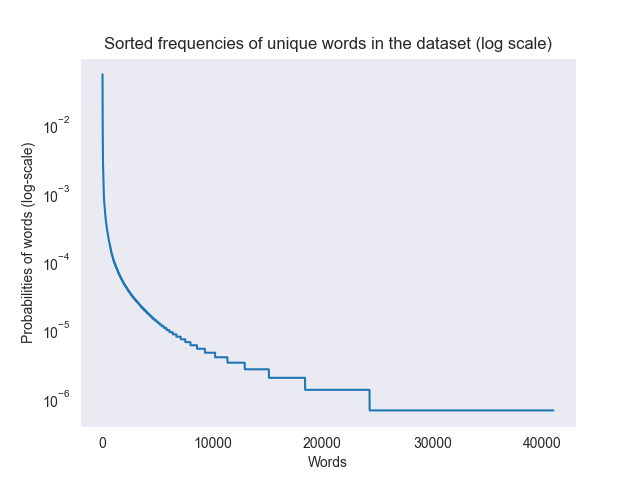

In [88]:
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.lineplot(df_filteredWordDescription["Frequency"]/df_filteredWordDescription["Frequency"].sum())
plt.yscale("log")

plt.title(f"Sorted frequencies of unique words in the dataset (log scale)")
plt.xlabel("Words")
plt.ylabel("Probabilities of words (log-scale)")
plt.show()

In this graph (log-lin scale), we clearly see that the proportion of word occurrence quickly drop after the first ten words and that after a thousand word, the proportions drops below 10E-5. In the end, this plot confirms what we observed with the table above: In most of the case, a word is very rare, appearing less than 10 times for over 75% of the time.

##### **Genres stats**
First how genres are distributed:

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Slice of life', 'Harem', 'School life', 'Supernatural', 'Yaoi', 'Mature', 'Adult', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Smut', 'Shounen ai', 'Xuanhuan', 'Historical', 'Seinen', 'Ecchi', 'Horror', 'Xianxia', 'Gender bender', 'Yuri', 'Mecha', 'Shoujo ai', 'Wuxia', 'Sports'], [7523, 6309, 4105, 3743, 3672, 3332, 2210, 2048, 1743, 1731, 1627, 1486, 1277, 1043, 1042, 984, 941, 935, 903, 886, 865, 784, 769, 673, 669, 639, 580, 406, 377, 313, 294, 184, 118, 112, 106]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_8060\3904004382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


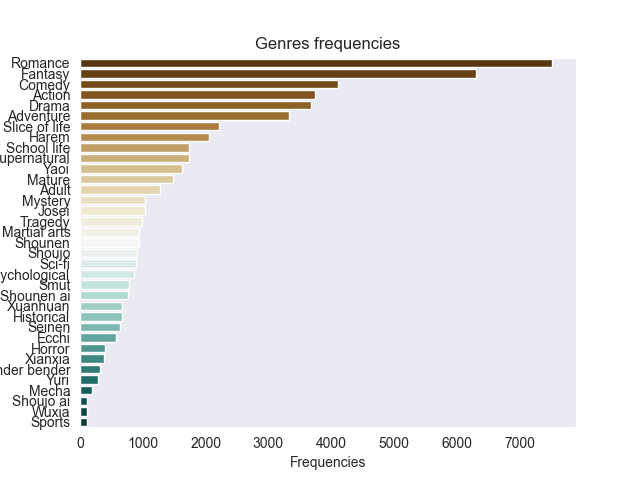

In [49]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_filtered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

In [32]:
genresCounterSorted

[['Romance',
  'Fantasy',
  'Comedy',
  'Action',
  'Drama',
  'Adventure',
  'Slice of life',
  'Harem',
  'School life',
  'Supernatural',
  'Yaoi',
  'Mature',
  'Adult',
  'Mystery',
  'Josei',
  'Tragedy',
  'Martial arts',
  'Shounen',
  'Shoujo',
  'Sci-fi',
  'Psychological',
  'Smut',
  'Shounen ai',
  'Xuanhuan',
  'Historical',
  'Seinen',
  'Ecchi',
  'Horror',
  'Xianxia',
  'Gender bender',
  'Yuri',
  'Mecha',
  'Shoujo ai',
  'Wuxia',
  'Sports'],
 [7523,
  6309,
  4105,
  3743,
  3672,
  3332,
  2210,
  2048,
  1743,
  1731,
  1627,
  1486,
  1277,
  1043,
  1042,
  984,
  941,
  935,
  903,
  886,
  865,
  784,
  769,
  673,
  669,
  639,
  580,
  406,
  377,
  313,
  294,
  184,
  118,
  112,
  106]]

Here we observe that some genres are really underrepresented. It is the case for `Sport`, `Gender Bender`, `Wuxia` and `Mecha`. In consequence, we will simply remove the labels in the dataset to facilitate our prediction.

Additionally, we are in the context where some tags are really close together and could be interchangeable. For example the tags `Shounen AI` and `Yaoi` are defined in the same way, but the focus is on the relationship within the boy-loves for the first and on more tendentious activities for the second (I do not read such things, so I could have made a mistake, but it is what results after some research on Internet). With different semantics, we can also have the same interchangeability remarks with the following genres:

- `Smut` vs `Adult`,
- `Xuanhuan` vs `Xianxia`
- `Yuri` vs `Shoujo AI`
- `Yaoi` vs `Shounen AI`

For the genres concerned, we will simply merge them.

In [33]:
# Dictionary of interchangeable genres
transferGenres = {
    "Smut":"Adult",
    "Shoujo ai":"Yuri",
    "Xianxia":"Xuanhuan",
    "Shounen ai":"Yaoi"
}
# Genres to remove
forbiddenGenres = set([
    "Sports",
    "Wuxia",
    "Mecha",
    "Gender bender"
])

# For each document
dfGenresFiltered = []
for genres in df_filtered.loc[:,"genres"]:
    genres_copy:list = genres.copy()
    
    # Changes the genres by removing/transforming the labels
    for genre in genres:
        if genre in forbiddenGenres:
            genres_copy.remove(genre)
        if genre in transferGenres:
            genres_copy.remove(genre)
            genres_copy.append(transferGenres[genre])
    dfGenresFiltered.append(genres_copy)

df_genresFiltered = df_filtered.copy(deep=True)
df_genresFiltered.loc[:, "genres"] = pd.Series(dfGenresFiltered)

What does it looks like after transformation?

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Yaoi', 'Slice of life', 'Adult', 'Harem', 'School life', 'Supernatural', 'Mature', 'Xuanhuan', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Historical', 'Seinen', 'Ecchi', 'Yuri', 'Horror'], [7523, 6309, 4105, 3743, 3672, 3332, 2396, 2210, 2061, 2048, 1743, 1731, 1486, 1050, 1043, 1042, 984, 941, 935, 903, 886, 865, 669, 639, 580, 412, 406]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_8060\3172256800.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


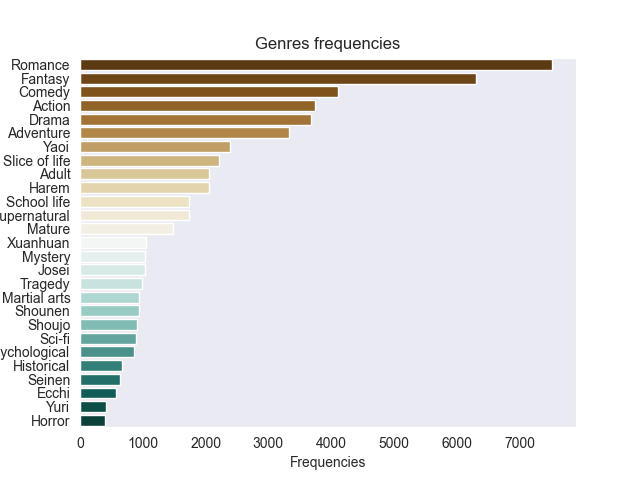

In [34]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_genresFiltered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

It turned good. Second, how do genres interacts togethers: 

In [89]:
# Create the genre id dictionary
genreToGenreID = {genre:i for i, genre in enumerate(set(genresList))}
genreIDtoGenre = {value:key for key, value in genreToGenreID.items()}
print(genreToGenreID, genreIDtoGenre, sep="\n")

# Create the genreCount dictionary
genreMatrix = np.zeros((len(genreIDtoGenre),len(genreIDtoGenre)), dtype=int)

## For all genres
for genres in df_genresFiltered.loc[:,"genres"].tolist():
    # If it is the only genre, then loop to itself
    if len(genres)==1:
        genreMatrix[genreToGenreID[genres[0]], genreToGenreID[genres[0]]] += 1
        continue
    # Otherwise, add a link to all couple of genre which are different
    for genre1 in genres:
        for genre2 in genres:
            if genre1 != genre2:
                genreMatrix[genreToGenreID[genre1], genreToGenreID[genre2]] += 1
#print(genreMatrix)

{'Fantasy': 0, 'Shounen': 1, 'Mecha': 2, 'Wuxia': 3, 'Mature': 4, 'Drama': 5, 'Historical': 6, 'Slice of life': 7, 'Xuanhuan': 8, 'Romance': 9, 'Adventure': 10, 'Tragedy': 11, 'Xianxia': 12, 'Shounen ai': 13, 'Comedy': 14, 'School life': 15, 'Action': 16, 'Seinen': 17, 'Josei': 18, 'Mystery': 19, 'Sci-fi': 20, 'Yuri': 21, 'Gender bender': 22, 'Sports': 23, 'Smut': 24, 'Yaoi': 25, 'Horror': 26, 'Shoujo ai': 27, 'Harem': 28, 'Shoujo': 29, 'Supernatural': 30, 'Psychological': 31, 'Martial arts': 32, 'Ecchi': 33, 'Adult': 34}
{0: 'Fantasy', 1: 'Shounen', 2: 'Mecha', 3: 'Wuxia', 4: 'Mature', 5: 'Drama', 6: 'Historical', 7: 'Slice of life', 8: 'Xuanhuan', 9: 'Romance', 10: 'Adventure', 11: 'Tragedy', 12: 'Xianxia', 13: 'Shounen ai', 14: 'Comedy', 15: 'School life', 16: 'Action', 17: 'Seinen', 18: 'Josei', 19: 'Mystery', 20: 'Sci-fi', 21: 'Yuri', 22: 'Gender bender', 23: 'Sports', 24: 'Smut', 25: 'Yaoi', 26: 'Horror', 27: 'Shoujo ai', 28: 'Harem', 29: 'Shoujo', 30: 'Supernatural', 31: 'Psycho

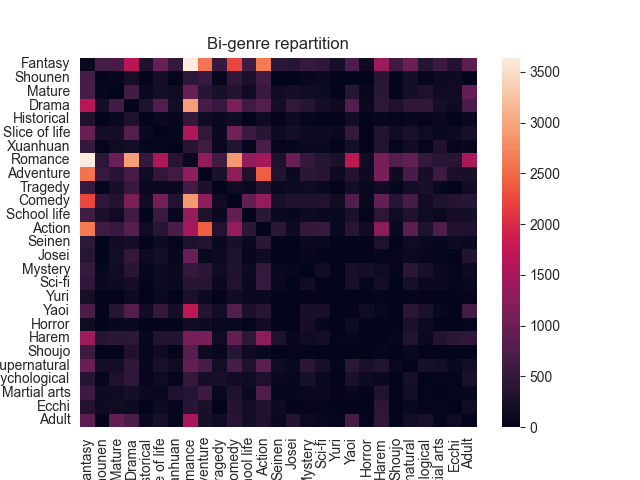

In [36]:
# Make a plot
plt.close("all")
sns.heatmap(genreMatrix,
            xticklabels=list(genreToGenreID.keys()),
            yticklabels=list(genreToGenreID.keys()))
plt.title("Bi-genre repartition")
plt.xlabel("Genre")
plt.ylabel("Genre")

plt.show()

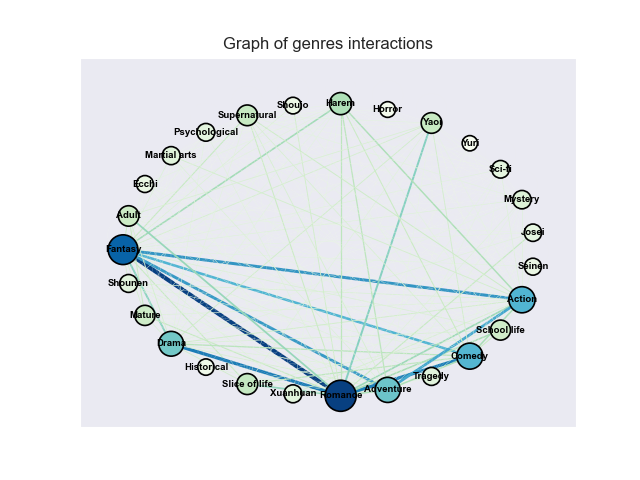

In [37]:
# Make the graph for visibility
G = nx.from_numpy_array(genreMatrix)
G = nx.relabel_nodes(G, dict(enumerate(list(genreToGenreID.keys()))))

# Compute the weights of each edges for the graph
weights = np.array(list(nx.get_edge_attributes(G,"weight").values()))
weights = weights/weights.max()

# Compute the degree of each node to infer nodes sizes
deg = dict(G.degree(weight="weight"))
node_sizes = [100 + 400 * deg[n] / max(deg.values()) for n in G.nodes()]

# Plot the graph
plt.close("all")
nx.draw_networkx(
                 G,                         # The graph 
                 pos=nx.shell_layout(G),    # The layout
                 width=3*weights,           # The width of the edges
                 edge_color=weights,        # Edge colour defined by the weights
                 edge_cmap=plt.cm.GnBu,     # Colour map of the edges
                 font_size="x-small",       # The font size
                 font_color="black",        # The font colour
                 font_weight="bold",        # We want bold
                 font_family="Arial",       # We want Arial
                 node_size=node_sizes,      # The size of the nodes
                 edgecolors="black",        # The border colour of the nodes
                 linewidths=1.2,            # Contour colour of the nodes
                 node_color=node_sizes,     # Colour of the node depends on the degree
                 cmap=plt.cm.GnBu           # Colour map of the nodes
)

# Show the graph
plt.title("Graph of genres interactions")
plt.show()

Here we observe some high correlation between genres which are going to either hinder our work or increase our predictive power depending on our classifications. For example, we have the triad `Adventure`, `Fantasy` and `Action` frequently appearing so if we have the two first, we could have a high chance of having the last.

In the end, the extensive study on the genres, allowed us to remove 9 of the original labels, letting us works from 35 genres to 26 genres. 

## 2.2 - Data Split
In this subpart we discuss data split strategies considering our multilabel situation. Indeed, in our case, doing a classic 60-20-20 split or a stratified split is not necessarily a good choice since multiple labels can appears, thus making balanced division difficult.

A first idea was to make a training-dev-test set for each possible labels, but this would mix the training/test data from one classifier to another while completely avoiding interdependence is impossible in our context.

This is why we will use [**scikit multilearn**](https://web.archive.org/web/20251114024511/https://scikit.ml/stratification.html) `iterative_train_test_split` function as suggested on the [*Data Science Stack Exchange*](https://datascience.stackexchange.com/questions/45174/how-to-use-sklearn-train-test-split-to-stratify-data-for-multi-label-classificat), which provide an optimised version of the classical train test split for multilabel.

In our situation, where we have a lot of classes and a decently sized dataset, we will use a 75-15-10 repartition.

In [ ]:
# To use the function: https://github.com/scikit-multilearn/scikit-multilearn/discussions/282

# Transform our labels lists into dummy classifier
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_genresFiltered.loc[:,"genres"].tolist())

# Transform our X into something working
X = df_genresFiltered[["description"]].to_numpy()
X = X[..., np.newaxis]

# Register the id of each labels (column of y)
labelIdtoLabelName = {i:label for i, label in enumerate(mlb.classes_)}
labelNameToLabelId = {v:k for k,v in labelIdtoLabelName.items()}

# Train Dev Test Split
## Train Test Split (0.75 training)
X_train, y_train, X_test, y_test = iterative_train_test_split(X, Y, test_size = 0.25)
## Test Dev split (0.6*0.25=0.15 dev and 0.4*0.25 = 0.1 test)
X_test, y_test, X_dev, y_dev = iterative_train_test_split(X_test, y_test, test_size=0.6)

# Print some informations:
print(
f"""
The shape of the training set is {X_train.shape},
the shape of the test set is {X_test.shape},
the shape of the dev set is {X_dev.shape}
"""
)


The shape of the training set is (8767, 1, 1),
the shape of the test set is (1180, 1, 1),
the shape of the dev set is (1823, 1, 1)



# 2.3 - Preprocessing Strategies


In [53]:
X_train

array([[['To sum up in a sentence, transmigrating to different worlds to wash slag men white every day, the goal is to become a good man!\nNote: slag men refer to men who play with women’s hearts aka scum and washing white means to come clean, fix up your life.\n']],

       [['Lin You He excelled in everything –  his looks and accomplishments were all top notch, but he was very dense in the emotional department that made people feel frustrated.\nEven if a marriage contract fell from the sky, he would not feel anything. All he knew was to remember his identity and fulfill the contract.\nOn the day of the wedding, he was still apologizing for his friends’ teasing.\n“I’m sorry Mr. Lu, they don’t know the situation, so I hope you don’t mind……”\nThe other party lowered his eyes to look at him, “I don’t mind.”\nLin Yu He felt relieved, as he thought that the rumors were wrong and that the other party was not as insensitive as he was rumored to be.\nUntil that night, he did not manage to get